#### imports

#### uses scipy.io to load the .arff file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

### load data and covert it in in dataframe 

In [2]:
data_raw, meta = arff.loadarff("data/shuttle.io.arff")
df = pd.DataFrame(data_raw)
print(df.shape)
df.head()

(58000, 10)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
0,50.0,21.0,77.0,0.0,28.0,0.0,27.0,48.0,22.0,b'2'
1,55.0,0.0,92.0,0.0,0.0,26.0,36.0,92.0,56.0,b'4'
2,53.0,0.0,82.0,0.0,52.0,-5.0,29.0,30.0,2.0,b'1'
3,37.0,0.0,76.0,0.0,28.0,18.0,40.0,48.0,8.0,b'1'
4,37.0,0.0,79.0,0.0,34.0,-26.0,43.0,46.0,2.0,b'1'


### checking the missing values like in air quality dataset we have some wrong values

In [3]:
df.isnull().sum()

A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
class    0
dtype: int64

#### like when we load .arff file then the output is in the categorical column bytes format (b'1') for that we have to covert it in integer 

In [4]:
df['class'] = df['class'].str.decode('utf-8').astype(int)
df['class'].value_counts()

class
1    45586
4     8903
5     3267
3      171
2       50
7       13
6       10
Name: count, dtype: int64

#### we have 7 classes in shuttle dataset but we need only 2 (normal/anomaly) so for that I consider classes 1,4  ( 0 ) as normal and rest anomaly ( 1 )

In [5]:
df['label'] = df['class'].apply(lambda x: 0 if x in [1, 4] else 1)
df['label'].value_counts()

label
0    54489
1     3511
Name: count, dtype: int64

### considered x as input ( features var) , y is only use for evaluation

In [6]:
X = df[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9']]
y = df['label']
print(X.shape, y.shape)

(58000, 9) (58000,)


### Train/Test Split -- since we labels so, took 30% of data for test and rest to check the results 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40600, 9)
Test shape: (17400, 9)


### Define parameters 

In [8]:
n_estimators = 100
contamination = 0.0605
sample_size = 256

### uses .fit(X_train) to train 

In [9]:
model = IsolationForest(
    n_estimators=n_estimators,
    contamination=contamination,
    max_samples=sample_size,
    random_state=42
)
model.fit(X_train)

,n_estimators,100
,max_samples,256
,contamination,0.0605
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


### predict -1/1 label , using x_test for evaluation

In [10]:
X_test_results = X_test.copy()
X_test_results['anomaly_score'] = model.decision_function(X_test)
X_test_results['anomaly'] = model.predict(X_test)

X_test_results['anomaly'].value_counts()

anomaly
 1    16353
-1     1047
Name: count, dtype: int64

### scatter plot

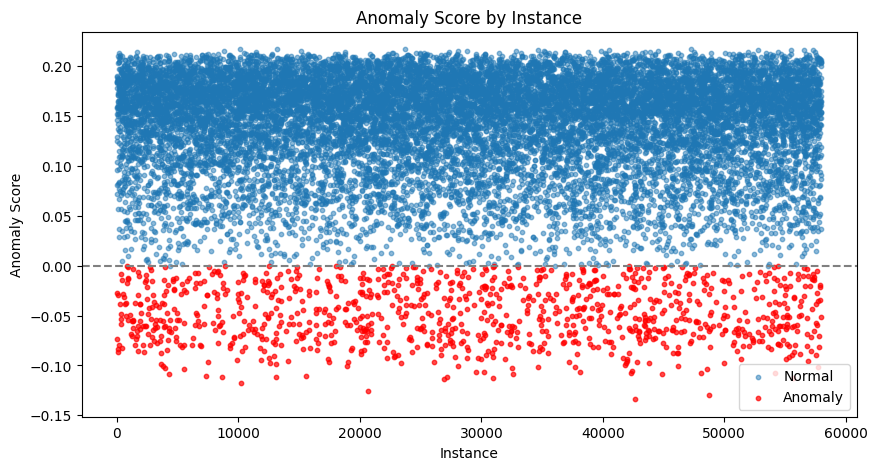

In [11]:
normal = X_test_results[X_test_results['anomaly'] == 1]
anomaly = X_test_results[X_test_results['anomaly'] == -1]

plt.figure(figsize=(10, 5))
plt.scatter(normal.index, normal['anomaly_score'], label='Normal', alpha=0.5, s=10)
plt.scatter(anomaly.index, anomaly['anomaly_score'], label='Anomaly', color='red', alpha=0.7, s=10)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Instance')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Score by Instance')
plt.legend()
plt.show()

### Evaluated using availables labels

In [12]:
y_pred = np.where(X_test_results['anomaly'] == -1, 1, 0)
anomaly_score_for_auc = -X_test_results['anomaly_score']

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, anomaly_score_for_auc)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Precision: 0.9426934097421203
Recall: 0.9373219373219374
F1-score: 0.94
ROC-AUC: 0.9959836501709628


### varies contamination values

In [13]:
contamination_values = [0.01, 0.03, 0.0605, 0.1, 0.15, 0.2]

for c in contamination_values:
    temp_model = IsolationForest(n_estimators=100, max_samples=256, contamination=c, random_state=42)
    temp_model.fit(X_train)
    temp_pred_raw = temp_model.predict(X_test)
    temp_pred = np.where(temp_pred_raw == -1, 1, 0)

    p = precision_score(y_test, temp_pred)
    r = recall_score(y_test, temp_pred)
    f = f1_score(y_test, temp_pred)

    print(f"contamination={c} -> Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

contamination=0.01 -> Precision=1.000, Recall=0.146, F1=0.255
contamination=0.03 -> Precision=1.000, Recall=0.466, F1=0.636
contamination=0.0605 -> Precision=0.943, Recall=0.937, F1=0.940
contamination=0.1 -> Precision=0.592, Recall=0.978, F1=0.738
contamination=0.15 -> Precision=0.390, Recall=0.987, F1=0.559
contamination=0.2 -> Precision=0.298, Recall=0.992, F1=0.459


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[16287    60]
 [   66   987]]
